In [7]:
pip install pandas numpy matplotlib seaborn textblob wordcloud nltk

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob
from wordcloud import WordCloud
import nltk

In [10]:
df = pd.read_csv("/content/chatgpt_reviews.csv")

df.head()

,review,rating,date
0,ChatGPT is extremely helpful for coding and le...,5,2024-01-01
1,"Great AI assistant, very useful for research.",5,2024-01-02
2,Sometimes the answers are inaccurate.,3,2024-01-03
3,Amazing tool for writing and brainstorming ideas.,5,2024-01-04
4,The responses are fast and helpful.,4,2024-01-05


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  10 non-null     object
 1   rating  10 non-null     int64 
 2   date    10 non-null     object
dtypes: int64(1), object(2)
memory usage: 372.0+ bytes


In [12]:
df.columns = df.columns.str.lower().str.strip()

In [13]:
df['review'] = df['review'].fillna("")
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df['date'] = pd.to_datetime(df['date'])

In [14]:
df.isnull().sum()

,0
review,0
rating,0
date,0


In [15]:
def get_sentiment(text):
    blob = TextBlob(text)
    return blob.sentiment.polarity, blob.sentiment.subjectivity

df[['polarity','subjectivity']] = df['review'].apply(
    lambda x: pd.Series(get_sentiment(x))
)

In [16]:
def label_sentiment(score):

    if score > 0:
        return "Positive"

    elif score < 0:
        return "Negative"

    else:
        return "Neutral"

df['sentiment'] = df['polarity'].apply(label_sentiment)

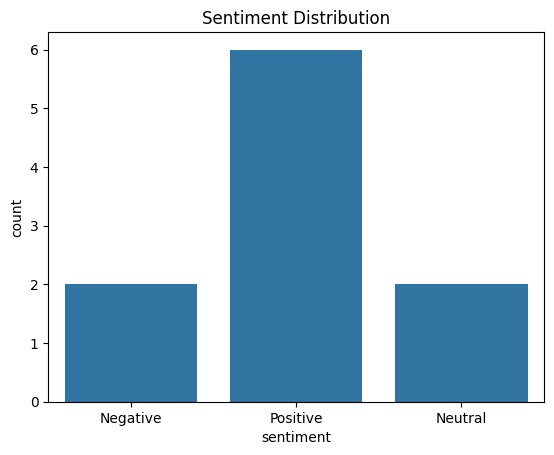

In [17]:
sns.countplot(data=df, x='sentiment')
plt.title("Sentiment Distribution")
plt.show()

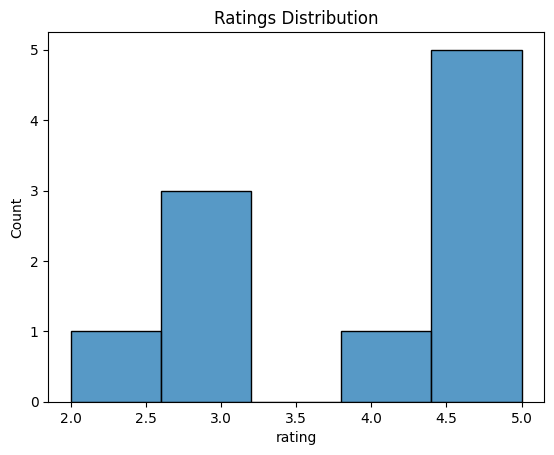

In [18]:
sns.histplot(df['rating'], bins=5)
plt.title("Ratings Distribution")
plt.show()

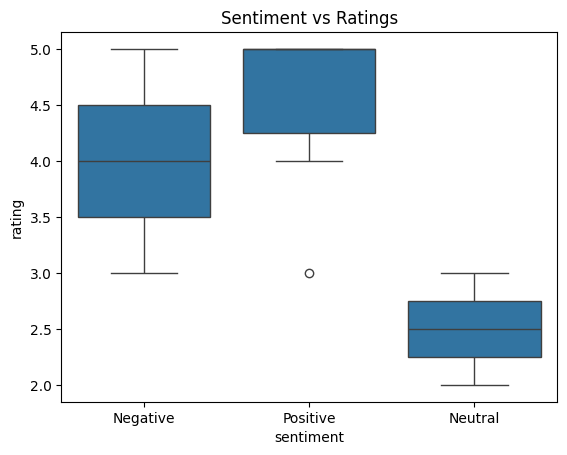

In [19]:
sns.boxplot(data=df, x='sentiment', y='rating')
plt.title("Sentiment vs Ratings")
plt.show()

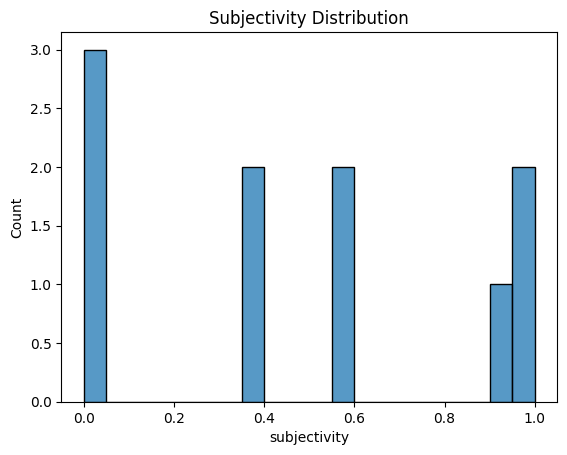

In [20]:
sns.histplot(df['subjectivity'], bins=20)
plt.title("Subjectivity Distribution")
plt.show()

In [21]:
positive_reviews = df[df['sentiment'] == "Positive"]

In [22]:
text = " ".join(positive_reviews['review'])

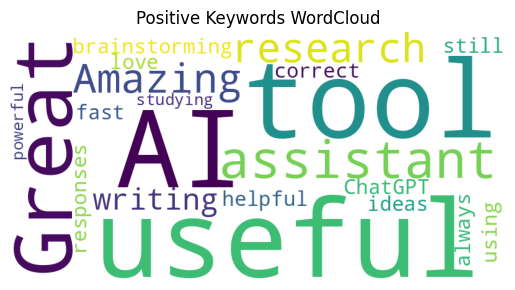

In [23]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.imshow(wordcloud)
plt.axis("off")
plt.title("Positive Keywords WordCloud")
plt.show()

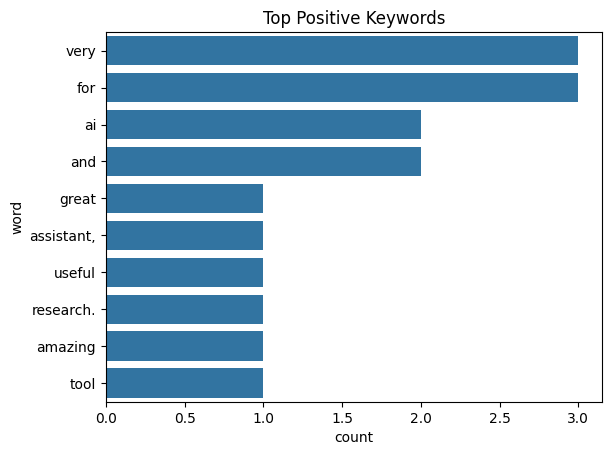

In [24]:
from collections import Counter

words = text.lower().split()

word_freq = Counter(words)

common_words = pd.DataFrame(
    word_freq.most_common(10),
    columns=["word","count"]
)

sns.barplot(data=common_words,x="count",y="word")
plt.title("Top Positive Keywords")
plt.show()